# Analiza aerodroma i ruta

Cilj je da se odgovori na sledeća pitanja:

1. Koliko ukupno ima aerodroma, a koliko ruta u skupu podataka?
2. Koji aerodromi imaju najveći broj polaznih ruta?
3. Koji aerodromi se najčešće pojavljuju kao odredišta?
4. Koje su najkraće, a koje najduže rute (na osnovu geografskih koordinata)?
5. Kako izgleda raspodela dužina ruta, da li preovlađuju kraći ili duži letovi?

**Ulazni fajlovi:**
- `airports.json`, lista aerodroma sa nazivom i koordinatama (geografska širina i dužina).
- `routes.json`, lista ruta sa polaznim i odredišnim aerodromom i njihovim koordinatama.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown, HTML

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 130

TABLE_STYLES = [
    {"selector": "th",
     "props": [("background-color", "#2c3e50"), ("color", "white"),
               ("padding", "10px 14px"), ("text-align", "left"),
               ("font-weight", "600"), ("font-family", "Segoe UI, Arial, sans-serif"),
               ("border", "none")]},
    {"selector": "td",
     "props": [("padding", "8px 14px"),
               ("font-family", "Segoe UI, Arial, sans-serif"),
               ("border-bottom", "1px solid #e0e6ed")]},
    {"selector": "tbody tr:nth-child(even)",
     "props": [("background-color", "#f5f7fa")]},
    {"selector": "tbody tr:hover",
     "props": [("background-color", "#dde6f0")]},
    {"selector": "table",
     "props": [("border-collapse", "collapse"),
               ("border-radius", "6px"), ("overflow", "hidden"),
               ("box-shadow", "0 1px 3px rgba(0,0,0,0.1)"),
               ("margin", "8px 0")]},
    {"selector": "caption",
     "props": [("caption-side", "top"), ("text-align", "left"),
               ("padding", "8px 0"), ("font-weight", "600"),
               ("font-size", "1.05em"), ("color", "#2c3e50")]},
]


def styled(df, gradient=None, cmap="Blues", precision=2, hide_index=True):
    s = df.style.set_table_styles(TABLE_STYLES).format(precision=precision, thousands=",")
    if hide_index:
        s = s.hide(axis="index")
    if gradient is not None:
        cols = [gradient] if isinstance(gradient, str) else list(gradient)
        cols = [c for c in cols if c in df.columns]
        if cols:
            s = s.background_gradient(subset=cols, cmap=cmap)
    return s


def pretty_info(df, naslov):
    info_df = pd.DataFrame({
        "#": range(len(df.columns)),
        "Kolona": df.columns,
        "Tip": [str(df[c].dtype) for c in df.columns],
        "Non-null": [f"{df[c].notna().sum():,} / {len(df):,}" for c in df.columns],
        "Jedinstvenih": [f"{df[c].nunique():,}" for c in df.columns],
    })
    mem_kb = df.memory_usage(deep=True).sum() / 1024
    display(Markdown(
        f"**{naslov}**: `{len(df):,}` redova, `{len(df.columns)}` kolona, "
        f"memorija ~`{mem_kb:.1f} KB`"
    ))
    return styled(info_df, hide_index=True)


print("Biblioteke i pomoćne funkcije učitane.")


Biblioteke i pomoćne funkcije učitane.


## 1. Učitavanje podataka

Oba JSON fajla učitavaju se u `pandas` DataFrame strukture. `airports_df` čuva podatke o aerodromima, a `routes_df` o rutama.

In [2]:
DATA_DIR = Path(".")
AIRPORTS_PATH = DATA_DIR / "airports.json"
ROUTES_PATH = DATA_DIR / "routes.json"

with AIRPORTS_PATH.open("r", encoding="utf-8") as f:
    airports_raw = json.load(f)

with ROUTES_PATH.open("r", encoding="utf-8") as f:
    routes_raw = json.load(f)

airports_df = pd.DataFrame(airports_raw)
routes_df = pd.DataFrame(routes_raw)

display(Markdown(
    f"- `airports_df`: **{airports_df.shape[0]:,}** redova x **{airports_df.shape[1]}** kolona  \n"
    f"- `routes_df`: **{routes_df.shape[0]:,}** redova x **{routes_df.shape[1]}** kolona"
))


- `airports_df`: **301** redova x **3** kolona  
- `routes_df`: **8,021** redova x **6** kolona

## 2. Osnovne informacije i prvi pogled na podatke

### 2.1 Aerodromi

In [3]:
pretty_info(airports_df, "Pregled DataFrame-a airports_df")


**Pregled DataFrame-a airports_df**: `301` redova, `3` kolona, memorija ~`22.5 KB`

#,Kolona,Tip,Non-null,Jedinstvenih
0,name,object,301 / 301,301
1,latitude,float64,301 / 301,300
2,longitude,float64,301 / 301,301


In [4]:
display(Markdown("**Prvih 10 aerodroma**"))
styled(airports_df.head(10), gradient=["latitude", "longitude"], cmap="YlGnBu", precision=4)


**Prvih 10 aerodroma**

name,latitude,longitude
Innsbruck INN,47.2602,11.3440
Linz LNZ,48.2332,14.1875
Salzburg SZG,47.7933,13.0043
Vienna VIE,48.1103,16.5697
Klagenfurt KLU,46.6425,14.3377
Brussels BRU,50.9014,4.4844
Brussels CRL,50.4592,4.4538
Bourgas BOJ,42.5696,27.5152
Plovdiv PDV,42.0678,24.8508
Sofia SOF,42.6967,23.4114


In [5]:
display(Markdown("**Statistika numeričkih kolona**"))
styled(airports_df.describe().round(2).reset_index().rename(columns={"index": "metrika"}),
       gradient=["latitude", "longitude"], cmap="YlGnBu")


**Statistika numeričkih kolona**

metrika,latitude,longitude
count,301.00,301.00
mean,47.59,9.46
std,8.20,11.53
min,27.93,-27.09
25%,42.40,0.52
50%,46.64,9.99
75%,52.18,18.72
max,70.07,33.62


### 2.2 Rute

In [6]:
pretty_info(routes_df, "Pregled DataFrame-a routes_df")


**Pregled DataFrame-a routes_df**: `8,021` redova, `6` kolona, memorija ~`1190.0 KB`

#,Kolona,Tip,Non-null,Jedinstvenih
0,src,object,"8,021 / 8,021",301
1,dst,object,"8,021 / 8,021",300
2,src_lat,float64,"8,021 / 8,021",300
3,src_lon,float64,"8,021 / 8,021",301
4,dst_lat,float64,"8,021 / 8,021",299
5,dst_lon,float64,"8,021 / 8,021",300


In [7]:
display(Markdown("**Prvih 10 ruta**"))
styled(routes_df.head(10),
       gradient=["src_lat", "src_lon", "dst_lat", "dst_lon"], cmap="YlGnBu", precision=2)


**Prvih 10 ruta**

src,dst,src_lat,src_lon,dst_lat,dst_lon
Innsbruck INN,London LGW,47.26,11.34,51.15,-0.19
Innsbruck INN,Amsterdam AMS,47.26,11.34,52.31,4.76
Linz LNZ,Bari BRI,48.23,14.19,41.14,16.76
Linz LNZ,Alicante ALC,48.23,14.19,38.28,-0.56
Linz LNZ,London STN,48.23,14.19,51.88,0.23
Salzburg SZG,London LTN,47.79,13.00,51.87,-0.37
Salzburg SZG,Alicante ALC,47.79,13.00,38.28,-0.56
Salzburg SZG,London STN,47.79,13.00,51.88,0.23
Salzburg SZG,Amsterdam AMS,47.79,13.00,52.31,4.76
Vienna VIE,Milan MXP,48.11,16.57,45.63,8.73


In [8]:
display(Markdown("**Statistika numeričkih kolona**"))
styled(routes_df.describe().round(2).reset_index().rename(columns={"index": "metrika"}),
       gradient=["src_lat", "src_lon", "dst_lat", "dst_lon"], cmap="YlGnBu")


**Statistika numeričkih kolona**

metrika,src_lat,src_lon,dst_lat,dst_lon
count,"8,021.00","8,021.00","8,021.00","8,021.00"
mean,46.06,7.76,46.07,7.78
std,7.30,11.04,7.29,11.03
min,27.93,-27.09,27.93,-27.09
25%,40.89,-0.48,40.89,-0.48
50%,45.67,7.65,45.67,7.65
75%,51.84,16.57,51.84,16.57
max,70.07,33.62,70.07,33.62


**Zaključak**: Skup `airports.json` sadrži tri kolone (`name`, `latitude`, `longitude`), a `routes.json` šest kolona (`src`, `dst`, `src_lat`, `src_lon`, `dst_lat`, `dst_lon`). Oba skupa imaju potpune (non-null) vrednosti, što znači da nije potrebna dodatna obrada nedostajućih podataka.

## 3. Pitanje 1: Koliko ima aerodroma i koliko ruta?

In [9]:
broj_aerodroma = len(airports_df)
broj_ruta = len(routes_df)
jedinstveni_polazni = routes_df["src"].nunique()
jedinstvena_odredista = routes_df["dst"].nunique()

sazetak = pd.DataFrame({
    "Pokazatelj": [
        "Broj aerodroma (airports.json)",
        "Broj ruta (routes.json)",
        "Jedinstveni polazni aerodromi u rutama",
        "Jedinstvena odredišta u rutama",
        "Prosečan broj ruta po aerodromu",
    ],
    "Vrednost": [
        f"{broj_aerodroma:,}",
        f"{broj_ruta:,}",
        f"{jedinstveni_polazni:,}",
        f"{jedinstvena_odredista:,}",
        f"{broj_ruta / broj_aerodroma:.1f}",
    ],
})
styled(sazetak)


Pokazatelj,Vrednost
Broj aerodroma (airports.json),301
Broj ruta (routes.json),"8,021"
Jedinstveni polazni aerodromi u rutama,301
Jedinstvena odredišta u rutama,300
Prosečan broj ruta po aerodromu,26.6


**Zaključak**: U skupu podataka postoji **301 aerodrom** i **8021 ruta**. Svi aerodromi pojavljuju se kao polazni (301), a 300 njih i kao odredište (samo jedan aerodrom je isključivo polazna tačka). Mreža je gusto povezana, prosečno na jedan aerodrom dolazi oko **27 ruta** (8021 / 301).

## 4. Pitanje 2: Aerodromi sa najvećim brojem polaznih ruta

Za svaki aerodrom se računa koliko puta se pojavljuje kao polazna tačka (`src`). Ispod je tabela sa **top 10 aerodroma** po broju polaznih ruta.

In [10]:
polazne_rute = (
    routes_df["src"]
    .value_counts()
    .rename_axis("aerodrom")
    .reset_index(name="broj_polaznih_ruta")
)

top10_polazni = polazne_rute.head(10).copy()
top10_polazni.insert(0, "rang", range(1, len(top10_polazni) + 1))

display(Markdown("**Top 10 aerodroma po broju polaznih ruta**"))
styled(top10_polazni, gradient="broj_polaznih_ruta", cmap="Blues", precision=0)


**Top 10 aerodroma po broju polaznih ruta**

rang,aerodrom,broj_polaznih_ruta
1,London STN,127
2,Barcelona BCN,119
3,Alicante ALC,119
4,Malaga AGP,117
5,Palma Mall PMI,112
6,Dublin DUB,110
7,Manchester MAN,107
8,London LGW,104
9,Brussels CRL,102
10,Oslo OSL,100


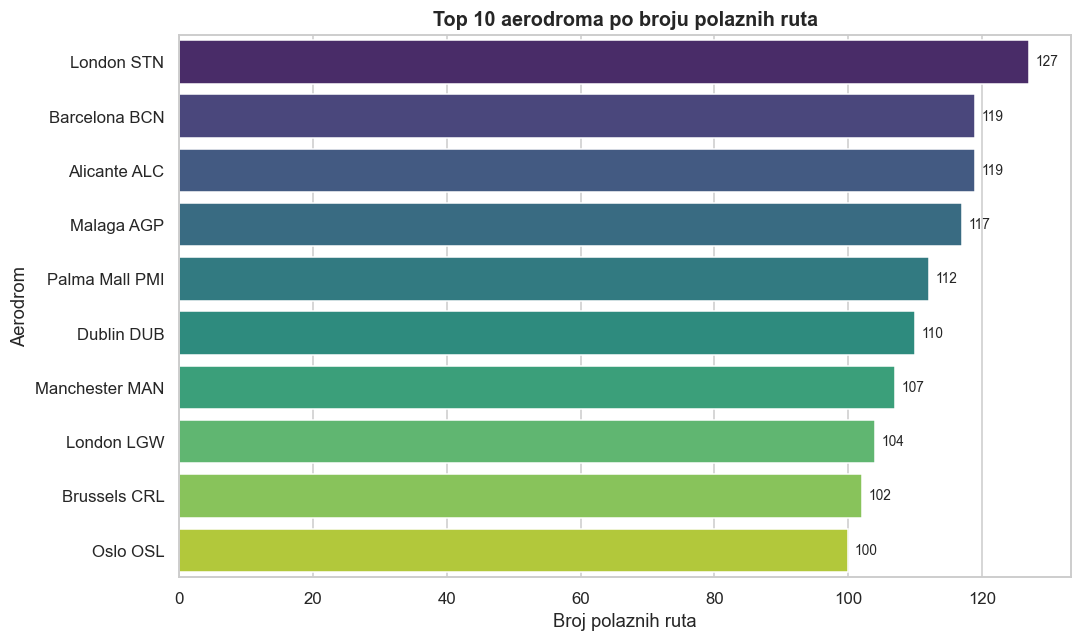

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=top10_polazni,
    y="aerodrom",
    x="broj_polaznih_ruta",
    hue="aerodrom",
    palette="viridis",
    legend=False,
    ax=ax,
)
ax.set_title("Top 10 aerodroma po broju polaznih ruta", fontsize=13, fontweight="bold")
ax.set_xlabel("Broj polaznih ruta")
ax.set_ylabel("Aerodrom")
for i, v in enumerate(top10_polazni["broj_polaznih_ruta"]):
    ax.text(v + 1, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.show()


**Zaključak**: Aerodrom sa najviše polaznih ruta je **London Stansted (STN)** sa **127 polaznih ruta**, što je očekivano jer je STN glavna baza Ryanair-a. Slede ga **Barcelona (BCN)**, **Alicante (ALC)**, **Malaga (AGP)** i **Palma de Mallorca (PMI)**, sa po više od 110 polaznih ruta. Karakteristično je da su sve top destinacije (osim Stansteda) španske, što odražava popularnost Španije kao turističke destinacije i njenu poziciju kao glavne baze nisko-tarifnih avio-kompanija.

## 5. Pitanje 3: Aerodromi koji se najčešće pojavljuju kao odredišta

Slično kao u prethodnom pitanju, ali se sada broje pojavljivanja u koloni `dst`.

In [12]:
dolazne_rute = (
    routes_df["dst"]
    .value_counts()
    .rename_axis("aerodrom")
    .reset_index(name="broj_dolaznih_ruta")
)

top10_destinacija = dolazne_rute.head(10).copy()
top10_destinacija.insert(0, "rang", range(1, len(top10_destinacija) + 1))

display(Markdown("**Top 10 aerodroma po broju dolaznih ruta**"))
styled(top10_destinacija, gradient="broj_dolaznih_ruta", cmap="Oranges", precision=0)


**Top 10 aerodroma po broju dolaznih ruta**

rang,aerodrom,broj_dolaznih_ruta
1,London STN,128
2,Barcelona BCN,124
3,Malaga AGP,119
4,Alicante ALC,118
5,Palma Mall PMI,114
6,Dublin DUB,113
7,Manchester MAN,107
8,London LGW,104
9,Brussels CRL,103
10,Oslo OSL,100


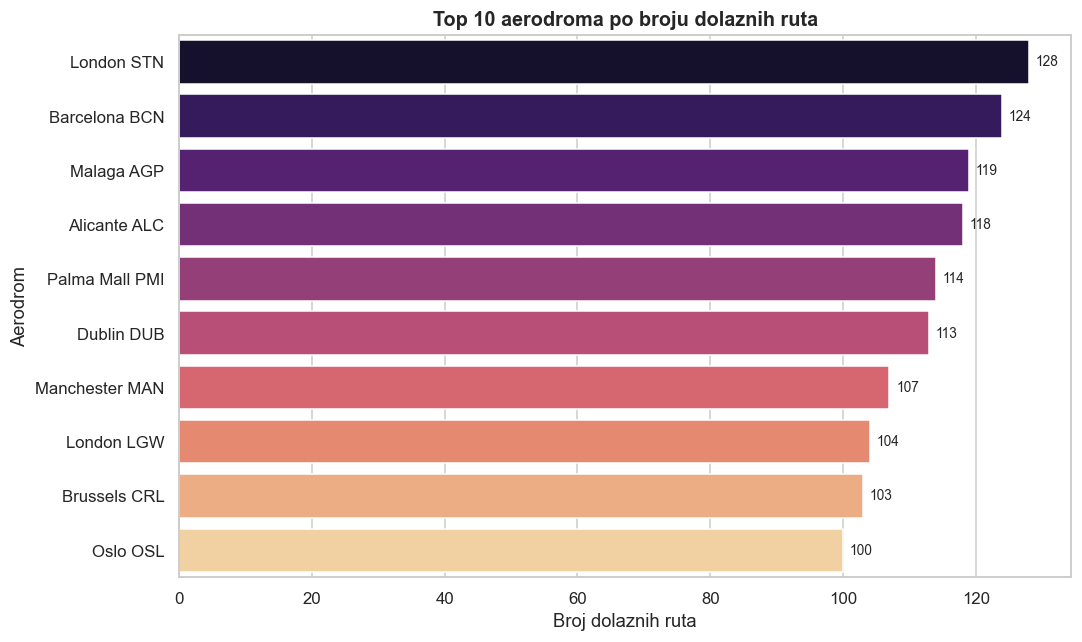

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=top10_destinacija,
    y="aerodrom",
    x="broj_dolaznih_ruta",
    hue="aerodrom",
    palette="magma",
    legend=False,
    ax=ax,
)
ax.set_title("Top 10 aerodroma po broju dolaznih ruta", fontsize=13, fontweight="bold")
ax.set_xlabel("Broj dolaznih ruta")
ax.set_ylabel("Aerodrom")
for i, v in enumerate(top10_destinacija["broj_dolaznih_ruta"]):
    ax.text(v + 1, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.show()


**Zaključak**: Lista najpopularnijih odredišta gotovo se podudara sa listom aerodroma sa najviše polaznih ruta. Na vrhu je opet **London Stansted (STN)** sa **128 dolaznih ruta**, slede **Barcelona BCN (124)**, **Malaga AGP (119)**, **Alicante ALC (118)** i **Palma PMI (114)**. Razlika u brojevima u odnosu na polazne rute je vrlo mala (uglavnom 1, 2 rute), što potvrđuje da je avio-saobraćaj gotovo u potpunosti dvosmeran, postojanje rute A do B obično prati i ruta B do A.

## 6. Pitanje 4: Najkraće i najduže rute (Haversine udaljenost)

Udaljenost između dve tačke na Zemlji (zadate geografskom širinom i dužinom) računa se **Haversinovom formulom**, koja uzima u obzir sferni oblik Zemlje:

$$
d = 2R \cdot \arcsin\left( \sqrt{ \sin^2\!\left(\frac{\Delta\varphi}{2}\right) + \cos\varphi_1 \cos\varphi_2 \sin^2\!\left(\frac{\Delta\lambda}{2}\right) } \right)
$$

gde je $R \approx 6371$ km poluprečnik Zemlje, $\varphi$ geografska širina i $\lambda$ geografska dužina, izraženi u radijanima. Rezultat je udaljenost po velikom krugu (najkraćoj putanji preko sferne površine), što je dobra aproksimacija stvarne dužine leta.

In [14]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    return 2.0 * R * np.arcsin(np.sqrt(a))


routes_df["distance_km"] = haversine_km(
    routes_df["src_lat"], routes_df["src_lon"],
    routes_df["dst_lat"], routes_df["dst_lon"],
).round(1)

display(Markdown("**Statistika dužina ruta (km)**"))
stat = routes_df["distance_km"].describe().round(2).reset_index()
stat.columns = ["metrika", "vrednost"]
styled(stat, gradient="vrednost", cmap="PuBu")


**Statistika dužina ruta (km)**

metrika,vrednost
count,"8,021.00"
mean,"1,456.94"
std,725.24
min,166.60
25%,913.50
50%,"1,336.80"
75%,"1,847.50"
max,"4,507.40"


### 6.1 Top 10 najkraćih ruta

In [15]:
najkrace = (
    routes_df.sort_values("distance_km", ascending=True)
    .loc[:, ["src", "dst", "distance_km"]]
    .head(10)
    .reset_index(drop=True)
)
najkrace.insert(0, "rang", range(1, len(najkrace) + 1))

display(Markdown("**10 najkraćih ruta**"))
styled(najkrace, gradient="distance_km", cmap="Greens_r", precision=1)


**10 najkraćih ruta**

rang,src,dst,distance_km
1,Belfast BHD,Glasgow GLA,166.6
2,Glasgow GLA,Belfast BHD,166.6
3,Tromso TOS,Alta ALF,173.8
4,Alta ALF,Tromso TOS,173.8
5,Ibiza IBZ,Valencia VLC,173.9
6,Glasgow GLA,Belfast BFS,176.0
7,Belfast BFS,Glasgow GLA,176.0
8,Alicante ALC,Ibiza IBZ,180.3
9,Ibiza IBZ,Alicante ALC,180.3
10,Dubrovnik DBV,Bari BRI,201.5


### 6.2 Top 10 najdužih ruta

In [16]:
najduze = (
    routes_df.sort_values("distance_km", ascending=False)
    .loc[:, ["src", "dst", "distance_km"]]
    .head(10)
    .reset_index(drop=True)
)
najduze.insert(0, "rang", range(1, len(najduze) + 1))

display(Markdown("**10 najdužih ruta**"))
styled(najduze, gradient="distance_km", cmap="Reds", precision=1)


**10 najdužih ruta**

rang,src,dst,distance_km
1,Riga RIX,Tenerife S TFS,"4,507.4"
2,Stockholm ARN,Gran Canar LPA,"4,334.9"
3,Gran Canar LPA,Stockholm ARN,"4,334.9"
4,Athens ATH,Reykjavik KEF,"4,200.7"
5,Bucharest OTP,Tenerife S TFS,"4,180.4"
6,Tenerife S TFS,Bucharest OTP,"4,180.4"
7,Tenerife S TFS,Oslo OSL,"4,129.1"
8,Oslo OSL,Tenerife S TFS,"4,129.1"
9,Oslo OSL,Gran Canar LPA,"4,096.9"
10,Gran Canar LPA,Oslo OSL,"4,096.9"


**Zaključak**: 

- **Najkraće rute** (~167 km) su između **Belfasta i Glazgova** (preko Irskog mora) i između **Tromsa i Alte** u severnoj Norveškoj. Sledi ih ruta Ibiza, Valencija (~174 km). Sve najkraće rute povezuju ostrvske ili izolovane destinacije sa najbližim kopnenim aerodromom.
- **Najduže rute** (preko 4000 km) sve vode ka **Kanarskim ostrvima** (Tenerife, Gran Canaria) iz udaljenih evropskih gradova: Riga, Stockholm, Bukurešt. Apsolutno najduža je **Riga, Tenerife (4507 km)**. Među najdužima je i Atina, Reykjavik koji povezuje južni i severni rub Evrope.
- Raspon dužina ruta je **od ~167 km do ~4507 km**, sa srednjom vrednošću **1457 km** i medijanom **1337 km**.

## 7. Pitanje 5: Raspodela dužina ruta

Histogram dužina ruta i opisna statistika daju uvid u to da li preovlađuju kraći ili duži letovi.

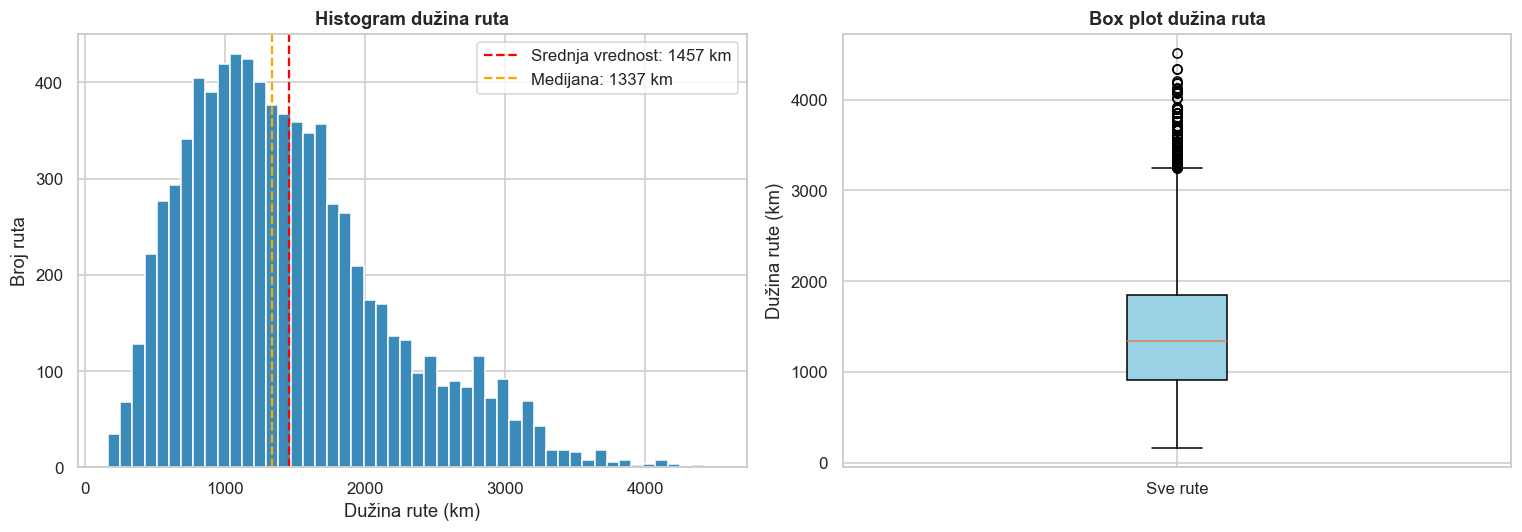

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(routes_df["distance_km"], bins=50, color="#3b8bba", edgecolor="white")
axes[0].set_title("Histogram dužina ruta", fontweight="bold")
axes[0].set_xlabel("Dužina rute (km)")
axes[0].set_ylabel("Broj ruta")
axes[0].axvline(routes_df["distance_km"].mean(), color="red", linestyle="--",
                label=f"Srednja vrednost: {routes_df['distance_km'].mean():.0f} km")
axes[0].axvline(routes_df["distance_km"].median(), color="orange", linestyle="--",
                label=f"Medijana: {routes_df['distance_km'].median():.0f} km")
axes[0].legend()

axes[1].boxplot(routes_df["distance_km"], vert=True, patch_artist=True,
                boxprops=dict(facecolor="#9bd1e5"))
axes[1].set_title("Box plot dužina ruta", fontweight="bold")
axes[1].set_ylabel("Dužina rute (km)")
axes[1].set_xticklabels(["Sve rute"])

plt.tight_layout()
plt.show()


In [18]:
bins = [0, 500, 1000, 2000, 3000, 5000, np.inf]
labels = ["0-500", "500-1000", "1000-2000", "2000-3000", "3000-5000", "5000+"]
routes_df["kategorija_duzine"] = pd.cut(
    routes_df["distance_km"], bins=bins, labels=labels, right=False,
)

raspodela = (
    routes_df["kategorija_duzine"]
    .value_counts()
    .reindex(labels)
    .reset_index(name="broj_ruta")
    .rename(columns={"index": "opseg_km"})
)
raspodela["procenat"] = (raspodela["broj_ruta"] / raspodela["broj_ruta"].sum() * 100).round(1)

display(Markdown("**Raspodela ruta po kategorijama dužine (km)**"))
styled(raspodela, gradient=["broj_ruta", "procenat"], cmap="Blues", precision=1)


**Raspodela ruta po kategorijama dužine (km)**

kategorija_duzine,broj_ruta,procenat
0-500,410,5.1
500-1000,"1,971",24.6
1000-2000,"4,022",50.1
2000-3000,"1,317",16.4
3000-5000,301,3.8
5000+,0,0.0


**Zaključak**: Raspodela dužina ruta je izrazito asimetrična u desnu stranu (right-skewed):

- **Polovina svih ruta (50.1%)** ima dužinu između **1000 i 2000 km** (4022 ruta), što odgovara letovima trajanja oko 1.5, 2.5 sata, tipičnim za evropski avio-saobraćaj.
- **Oko 30%** ruta je kraće od 1000 km (kratki letovi do 1.5 sata): 410 ruta (5.1%) je 0, 500 km, a 1971 ruta (24.6%) 500, 1000 km.
- **Letovi 2000, 3000 km** (16.4%, 1317 ruta) uglavnom povezuju krajnje delove Evrope.
- **Letovi preko 3000 km** su retkost (~3.8%, 301 ruta) i uglavnom vode ka prekomorskim destinacijama (Kanarska ostrva, Azori, Madeira, Reykjavik).
- **Nijedna ruta** u skupu nije duža od **5000 km**, što potvrđuje da se ovde radi o evropskoj (kontinentalnoj) avio-mreži, bez interkontinentalnih letova.

Zaključak: **preovlađuju kraći letovi**, jasno je da se radi o tipičnom evropskom skupu nisko-tarifnih ruta.

## 8. aerodroma po geografskim koordinatama

Scatter plot prikazuje sve aerodrome na mapi (geografska dužina na x-osi, širina na y-osi). Za svaki aerodrom veličina tačke proporcionalna je broju polaznih + dolaznih ruta, što vizuelno ističe glavne hub-ove.

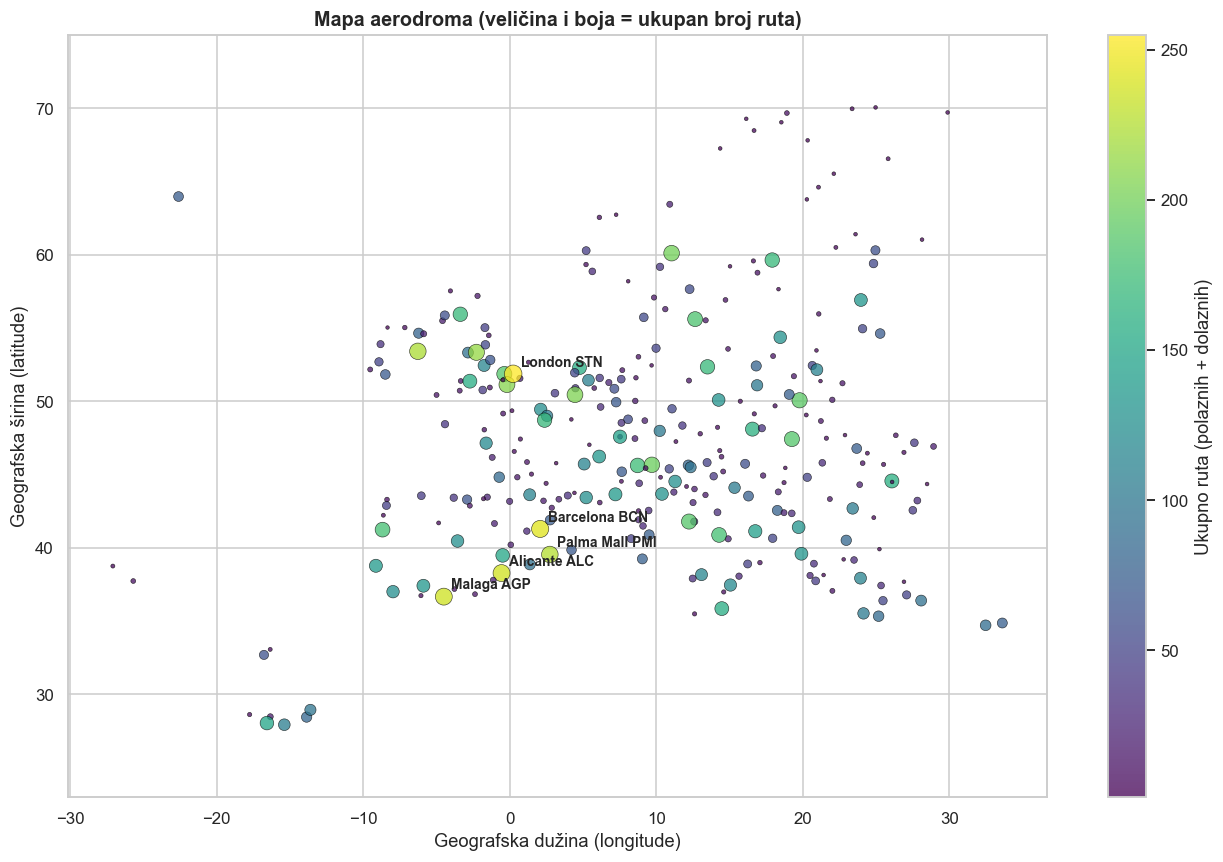

In [20]:
ukupno_ruta_po_aerodromu = (
    pd.concat([routes_df["src"], routes_df["dst"]])
    .value_counts()
    .rename_axis("aerodrom")
    .reset_index(name="ukupno_ruta")
)

mapa_df = airports_df.merge(
    ukupno_ruta_po_aerodromu, left_on="name", right_on="aerodrom", how="left",
)
mapa_df["ukupno_ruta"] = mapa_df["ukupno_ruta"].fillna(0)

fig, ax = plt.subplots(figsize=(12, 8))
sc = ax.scatter(
    mapa_df["longitude"], mapa_df["latitude"],
    s=mapa_df["ukupno_ruta"] * 0.5 + 5,
    c=mapa_df["ukupno_ruta"], cmap="viridis",
    alpha=0.75, edgecolors="black", linewidths=0.4,
)
plt.colorbar(sc, ax=ax, label="Ukupno ruta (polaznih + dolaznih)")

top5 = mapa_df.nlargest(5, "ukupno_ruta")
for _, row in top5.iterrows():
    ax.annotate(
        row["name"], (row["longitude"], row["latitude"]),
        fontsize=9, fontweight="bold",
        xytext=(5, 5), textcoords="offset points",
    )

ax.set_title("Mapa aerodroma (veličina i boja = ukupan broj ruta)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Geografska dužina (longitude)")
ax.set_ylabel("Geografska širina (latitude)")
ax.set_aspect("equal", adjustable="datalim")
plt.tight_layout()
plt.show()


**Zaključak**: Mapa jasno pokazuje koncentraciju aerodroma u centralnoj i zapadnoj Evropi (Velika Britanija, Italija, Nemačka, Francuska, Španija). Najveći hub-ovi se ističu kao najveće i najsvetlije tačke, dok su udaljene destinacije (Island, Kanarska ostrva, severni delovi Skandinavije) prikazane kao izolovane male tačke.

## 9. Sažetak

- **Skup podataka**: **301 aerodrom** i **8021 ruta** u evropskoj avio-mreži.
- **Najveći hub-ovi**: London Stansted (STN), Barcelona (BCN), Alicante (ALC), Malaga (AGP), Palma (PMI). Većinu čine baze nisko-tarifnih avio-kompanija i popularne španske turističke destinacije.
- **Najkraće rute** (~167 km): Belfast, Glasgow, Tromso, Alta, Ibiza, Valencia.
- **Najduže rute** (preko 4000 km): povezuju udaljene evropske gradove sa Kanarskim ostrvima i Reykjavikom.
- **Raspodela dužina ruta** je asimetrična u desnu stranu, ~80% ruta je kraće od 2000 km, što potvrđuje da je evropski avio-saobraćaj dominantno regionalan.
- **Mapa aerodroma** vizuelno potvrđuje da je avio-mreža najgušća u centralnoj i zapadnoj Evropi (Velika Britanija, Italija, Nemačka, Francuska, Španija), dok su severne i ostrvske destinacije (Kanari, Azori, Madeira, Skandinavija) izolovaniji čvorovi sa manjim brojem ruta.